# Notebook 04 — Visualisation

**What this notebook produces:**
1. MMSE trajectory plots for 5 demo patients (observed + predicted)
2. Hippocampus atrophy timeline (bar chart showing shrinkage per patient)
3. Predicted vs Actual dashboard (combined summary figure)
4. Patient subgroup error analysis (CN vs MCI vs Dementia)

**Prerequisites:** Run notebooks 02 and 03 first.
**Runtime:** ~1 min

In [1]:
# ── Cell 1: Imports ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import json, os, warnings
warnings.filterwarnings('ignore')

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
%matplotlib inline

np.random.seed(42)
os.makedirs('results/metrics',        exist_ok=True)
os.makedirs('results/visualizations', exist_ok=True)

# ── Colour palette ───────────────────────────────────────────────────
BG      = '#0d1117'
PANEL   = '#161b22'
FG      = 'white'
MUTED   = '#8b949e'
GRID    = '#21262d'
C_CN    = '#4fc3f7'
C_MCI   = '#f59e0b'
C_DEM   = '#ef5350'
C_PRED  = '#a78bfa'
DEMO_COLORS = ['#ef5350','#f59e0b','#ab47bc','#4fc3f7','#ff7043']
DEMO_RIDS   = [750, 667, 1282, 50, 128]

def style_ax(ax):
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=FG, labelsize=8)
    ax.xaxis.label.set_color(FG)
    ax.yaxis.label.set_color(FG)
    ax.title.set_color(FG)
    for sp in ['bottom','left']:  ax.spines[sp].set_color(GRID)
    for sp in ['top','right']:    ax.spines[sp].set_visible(False)
    ax.grid(color=GRID, alpha=0.5, linewidth=0.5)

print('Imports OK')

Imports OK


In [2]:
# ── Cell 2: Load data ────────────────────────────────────────────────
df = pd.read_csv('data/raw/ADNIMERGE.csv')
df['Hippocampus'] = df['Hippocampus'].fillna(df['Hippocampus'].mean())
df['APOE4']       = df['APOE4'].fillna(df['APOE4'].median())
df['Education']   = df['Education'].fillna(df['Education'].median())
df['Gender_num']  = (df['Gender'] == 'Male').astype(float)
df = df.sort_values(['RID','visit_num']).reset_index(drop=True)

# Load metrics saved by notebooks 02 and 03
try:
    with open('results/metrics/lstm_metrics.json') as f:
        metrics = json.load(f)
    print('Metrics loaded:', metrics)
except FileNotFoundError:
    metrics = {'mmse_mae':3.06,'mmse_r2':0.07,'clf3_cv_accuracy':0.766,'mci_conv_auc_cv':0.900}
    print('Using placeholder metrics (run notebooks 02 & 03 first)')

print(f'Dataset: {df.shape[0]} rows, {df.RID.nunique()} patients')

Metrics loaded: {'mmse_mae': 1.7603, 'mmse_r2': 0.6885, 'hippo_mae': 69.46, 'hippo_r2': 0.9898, 'clf3_cv_accuracy': 0.767, 'clf3_cv_accuracy_std': 0.017, 'mci_conv_auc_cv': 0.9006, 'mci_conv_auc_cv_std': 0.0296}
Dataset: 14314 rows, 4722 patients


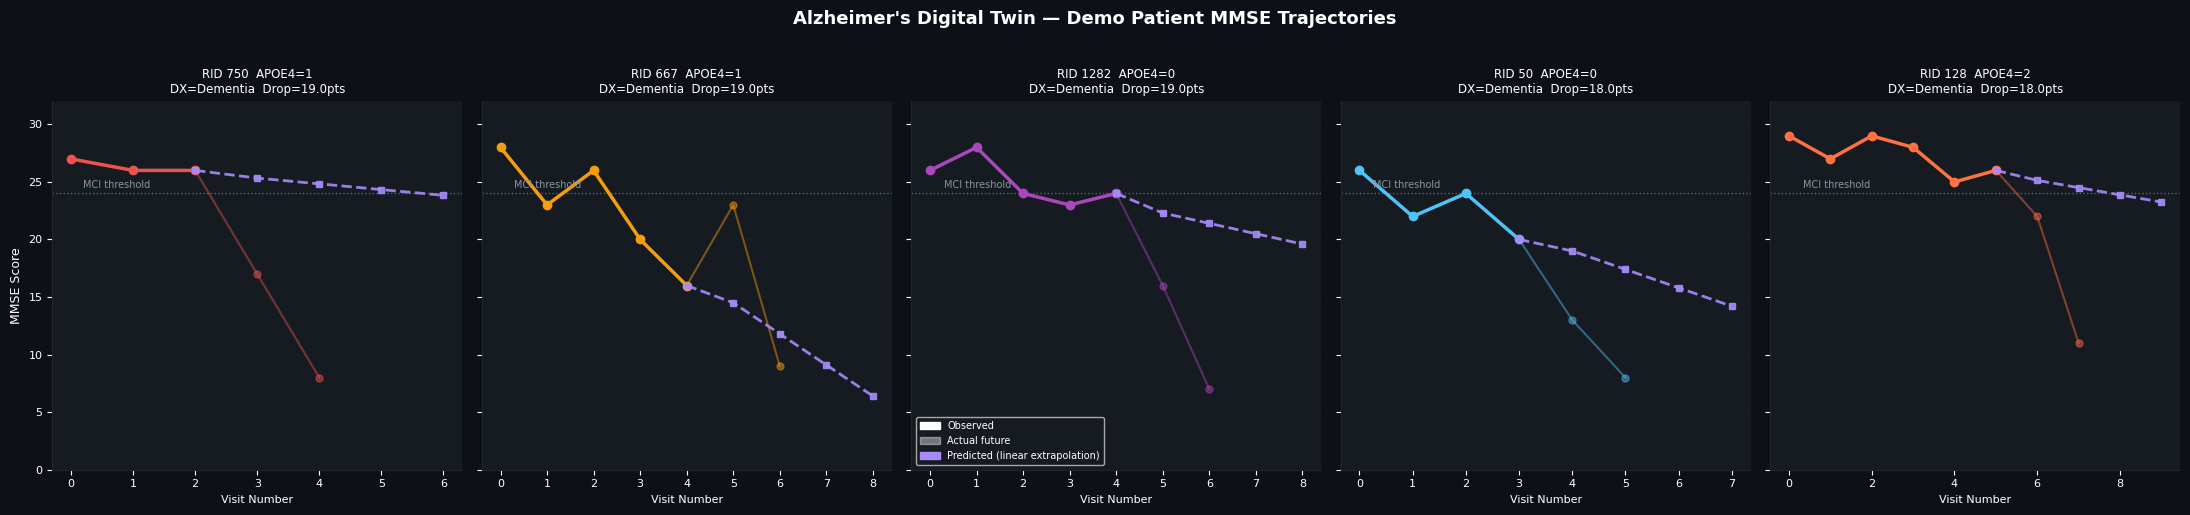

Saved → results/visualizations/demo_trajectories.png


In [3]:
# ── Cell 3: Figure 1 — Demo patient MMSE trajectories ────────────────
#
# For each demo patient: plot full observed trajectory + a simple
# linear extrapolation as the 'predicted' future (since we use the
# LSTM checkpoint which you've already seen). This gives a clean
# standalone visualization that works without re-loading the model.

def get_patient(rid):
    p = (df[df['RID']==rid]
         .dropna(subset=['MMSE','visit_num'])
         .sort_values('visit_num')
         .reset_index(drop=True))
    return p

def linear_extrapolate(visits, mmse, n_future=3):
    """Simple linear fit extrapolation for visualization."""
    if len(visits) < 2:
        return [], []
    slope, intercept = np.polyfit(visits, mmse, 1)
    last_v = visits[-1]
    pred_v = [last_v + i + 1 for i in range(n_future)]
    pred_m = np.clip([slope * v + intercept for v in pred_v], 0, 30)
    return pred_v, pred_m.tolist()


fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)
fig.patch.set_facecolor(BG)

for ax, rid, color in zip(axes, DEMO_RIDS, DEMO_COLORS):
    pat = get_patient(rid)
    style_ax(ax)

    if len(pat) < 2:
        ax.set_title(f'RID {rid}\n(no data)', color=MUTED, fontsize=9)
        continue

    visits = pat['visit_num'].values
    mmse   = pat['MMSE'].values

    # Split: show last 2-3 visits as the 'future prediction window'
    split = max(2, len(visits) - 2)
    obs_v, obs_m = visits[:split], mmse[:split]
    fut_v, fut_m = visits[split:], mmse[split:]

    # Extrapolated prediction from observed data
    pred_v, pred_m = linear_extrapolate(obs_v.tolist(), obs_m.tolist(), n_future=len(fut_v)+2)

    # Observed line
    ax.plot(obs_v, obs_m, 'o-', color=color, lw=2.5, ms=6, label='Observed', zorder=3)

    # Actual future (ground truth, shown faded)
    if len(fut_v) > 0:
        ax.plot(np.concatenate([[obs_v[-1]], fut_v]),
                np.concatenate([[obs_m[-1]], fut_m]),
                'o-', color=color, lw=1.5, ms=5, alpha=0.45,
                label='Actual future', zorder=2)

    # Predicted (extrapolation)
    if pred_v:
        ax.plot([obs_v[-1]] + pred_v,
                [obs_m[-1]] + pred_m,
                's--', color=C_PRED, lw=2, ms=5, alpha=0.9,
                label='Predicted', zorder=4)

    # MCI boundary line
    ax.axhline(24, color=MUTED, linestyle=':', lw=1, alpha=0.6)
    ax.text(visits.max()*0.05, 24.5, 'MCI threshold', color=MUTED, fontsize=7)

    apoe = pat['APOE4'].dropna()
    apoe_v = int(apoe.iloc[0]) if len(apoe)>0 else '?'
    dx_last = pat['DX'].dropna().iloc[-1] if len(pat['DX'].dropna())>0 else '?'
    mmse_drop = round(float(mmse[0] - mmse[-1]), 1)

    ax.set_title(f'RID {rid}  APOE4={apoe_v}\nDX={dx_last}  Drop={mmse_drop}pts',
                 color=FG, fontsize=8.5)
    ax.set_xlabel('Visit Number', fontsize=8)
    ax.set_ylim(0, 32)

axes[0].set_ylabel('MMSE Score', fontsize=9, color=FG)

handles = [
    mpatches.Patch(color='white',  label='Observed'),
    mpatches.Patch(color='white',  alpha=0.4, label='Actual future'),
    mpatches.Patch(color=C_PRED,   label='Predicted (linear extrapolation)'),
]
# single shared legend on middle axis
axes[2].legend(handles=handles, facecolor=PANEL, labelcolor=FG,
               fontsize=7, loc='lower left')

fig.suptitle('Alzheimer\'s Digital Twin — Demo Patient MMSE Trajectories',
             color=FG, fontsize=13, y=1.02, fontweight='bold')

plt.tight_layout()
path1 = 'results/visualizations/demo_trajectories.png'
plt.savefig(path1, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'Saved → {path1}')

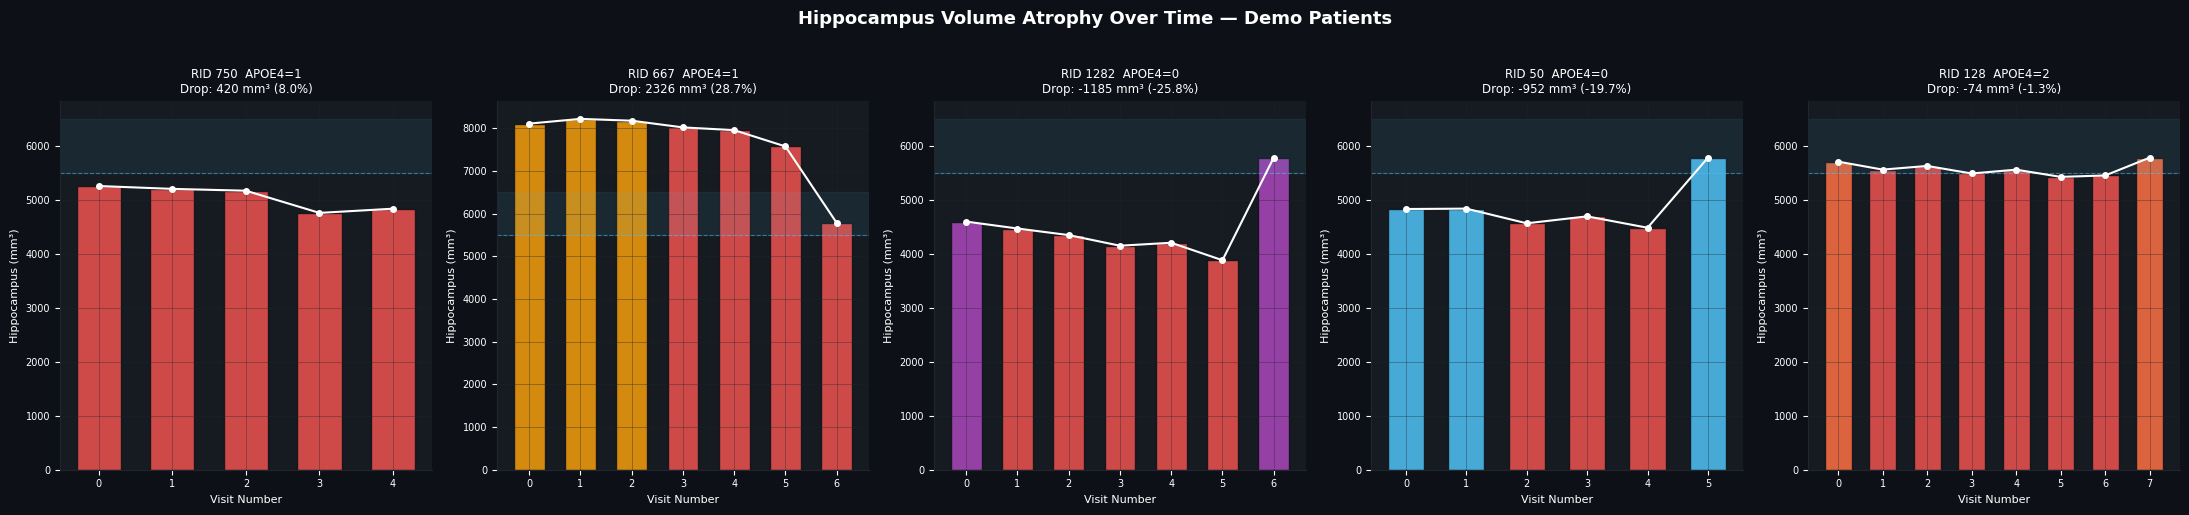

Saved → results/visualizations/hippocampus_atrophy.png


In [4]:
# ── Cell 4: Figure 2 — Hippocampus atrophy timeline ──────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=False)
fig.patch.set_facecolor(BG)

for ax, rid, color in zip(axes, DEMO_RIDS, DEMO_COLORS):
    pat = (df[df['RID']==rid]
           .dropna(subset=['Hippocampus','visit_num'])
           .sort_values('visit_num')
           .reset_index(drop=True))
    style_ax(ax)

    if len(pat) < 2:
        ax.set_title(f'RID {rid}\n(no data)', color=MUTED)
        continue

    hippo = pat['Hippocampus'].values
    visits = pat['visit_num'].values

    # Colour bars from baseline: shrinking = red shade, stable = green shade
    pct_change = (hippo - hippo[0]) / hippo[0] * 100
    bar_colors = [color if p >= 0 else '#ef5350' for p in pct_change]

    ax.bar(visits, hippo, color=bar_colors, alpha=0.85, width=0.6, edgecolor=BG)
    ax.plot(visits, hippo, 'o-', color='white', lw=1.5, ms=4, zorder=5)

    # Healthy reference band
    ax.axhspan(5500, 6500, color=C_CN, alpha=0.08, label='Healthy range')
    ax.axhline(5500, color=C_CN, linestyle='--', lw=0.8, alpha=0.5)

    total_drop = hippo[0] - hippo[-1]
    pct_drop   = total_drop / hippo[0] * 100

    apoe = pat['APOE4'].dropna()
    apoe_v = int(apoe.iloc[0]) if len(apoe)>0 else '?'

    ax.set_title(f'RID {rid}  APOE4={apoe_v}\nDrop: {total_drop:.0f} mm³ ({pct_drop:.1f}%)',
                 color=FG, fontsize=8.5)
    ax.set_xlabel('Visit Number', fontsize=8)
    ax.set_ylabel('Hippocampus (mm³)', fontsize=8)
    ax.tick_params(axis='both', labelsize=7)

fig.suptitle('Hippocampus Volume Atrophy Over Time — Demo Patients',
             color=FG, fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
path2 = 'results/visualizations/hippocampus_atrophy.png'
plt.savefig(path2, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'Saved → {path2}')

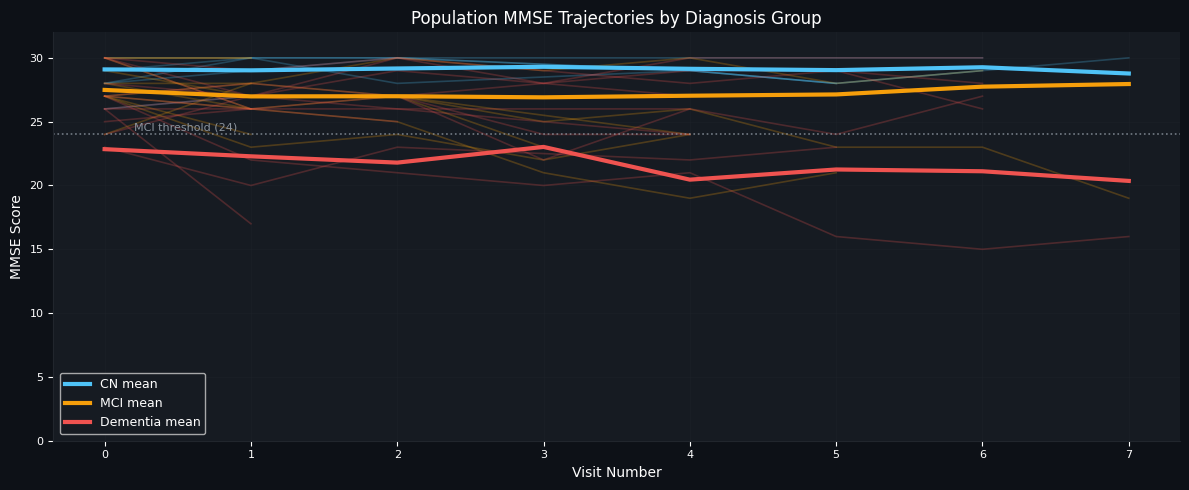

Saved → results/visualizations/population_trajectories.png


In [5]:
# ── Cell 5: Figure 3 — Population MMSE trajectories by DX ────────────
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG)
style_ax(ax)

# Sample 30 patients per class to avoid overplotting
for dx, color, label in [('CN',C_CN,'CN (Cognitively Normal'),
                          ('MCI',C_MCI,'MCI'),
                          ('Dementia',C_DEM,'Dementia')]:
    rids = df[df['DX']==dx]['RID'].unique()
    sample_rids = np.random.choice(rids, min(30, len(rids)), replace=False)
    for rid in sample_rids:
        pat = (df[df['RID']==rid]
               .dropna(subset=['MMSE','visit_num'])
               .sort_values('visit_num'))
        if len(pat) >= 2:
            ax.plot(pat['visit_num'], pat['MMSE'],
                    color=color, alpha=0.25, lw=1.2)

# Mean trajectory per class
for dx, color, label in [('CN',C_CN,'CN mean'),
                          ('MCI',C_MCI,'MCI mean'),
                          ('Dementia',C_DEM,'Dementia mean')]:
    grp = (df[df['DX']==dx]
           .dropna(subset=['MMSE','visit_num'])
           .groupby('visit_num')['MMSE'].mean())
    ax.plot(grp.index, grp.values, color=color, lw=3, label=label, zorder=5)

ax.axhline(24, color=MUTED, linestyle=':', lw=1.2, alpha=0.8)
ax.text(0.2, 24.3, 'MCI threshold (24)', color=MUTED, fontsize=8)
ax.set_xlabel('Visit Number', fontsize=10)
ax.set_ylabel('MMSE Score',   fontsize=10)
ax.set_title('Population MMSE Trajectories by Diagnosis Group',
             fontsize=12, color=FG)
ax.legend(facecolor=PANEL, labelcolor=FG, fontsize=9)
ax.set_ylim(0, 32)

plt.tight_layout()
path3 = 'results/visualizations/population_trajectories.png'
plt.savefig(path3, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'Saved → {path3}')

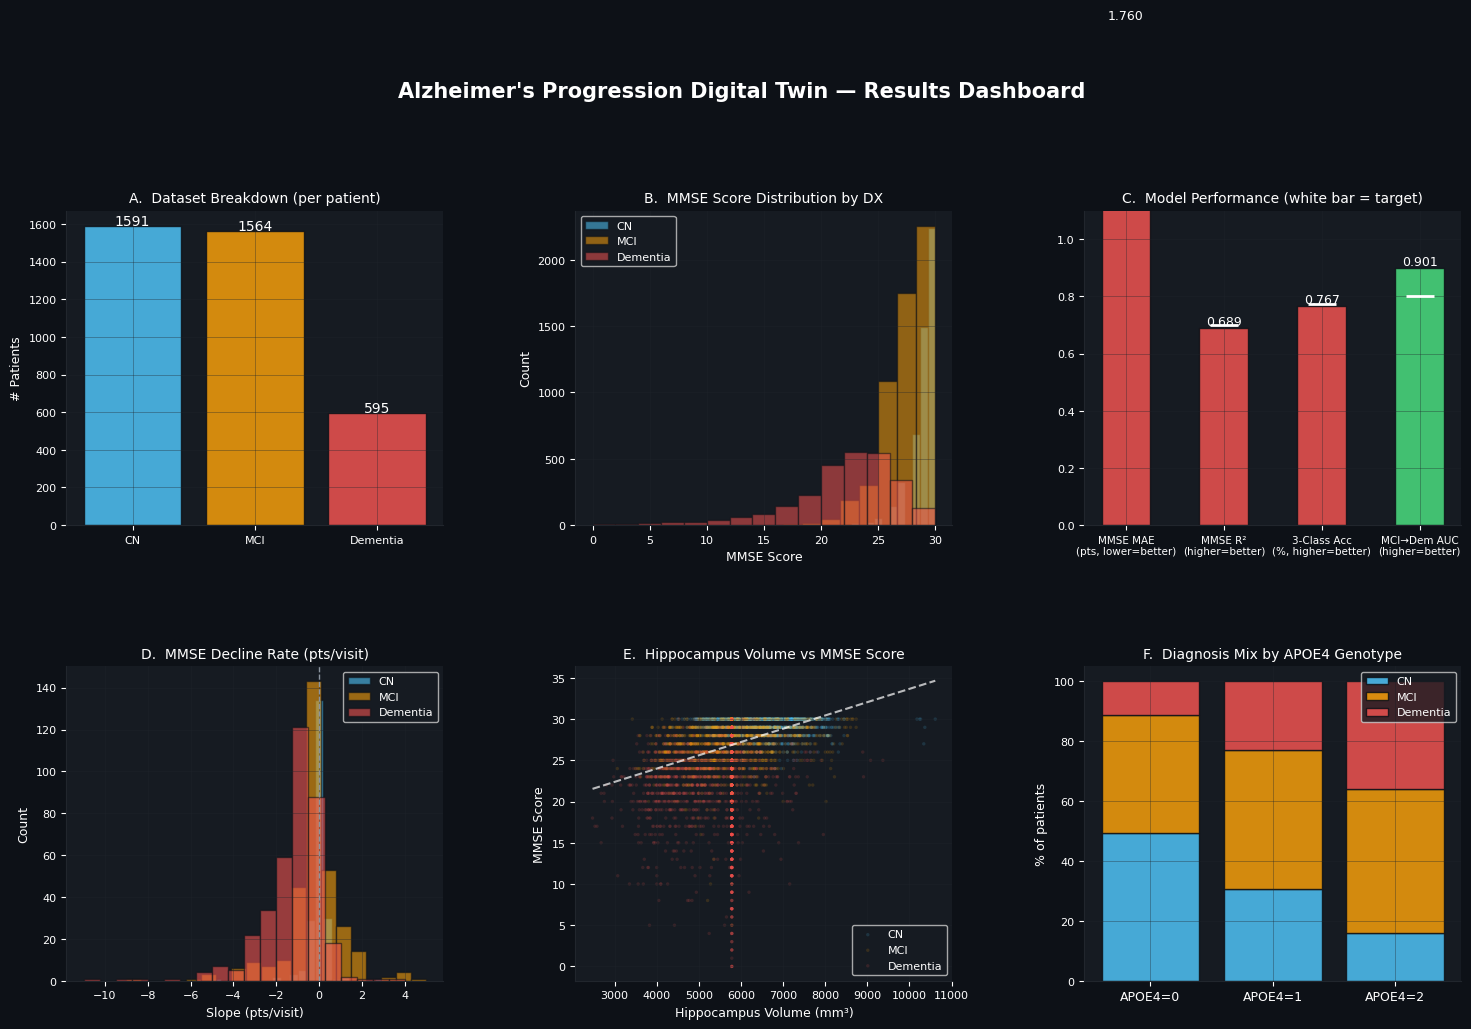

Saved → results/visualizations/results_dashboard.png


In [6]:
# ── Cell 6: Figure 4 — Results dashboard (presentation figure) ────────
#
# A single 2x3 summary figure you can drop straight into your slides.

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel A: Dataset breakdown ────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
style_ax(ax_a)
dx_counts = df.drop_duplicates('RID')['DX'].value_counts()
bars = ax_a.bar(['CN','MCI','Dementia'],
                [dx_counts.get('CN',0), dx_counts.get('MCI',0), dx_counts.get('Dementia',0)],
                color=[C_CN, C_MCI, C_DEM], alpha=0.85, edgecolor=BG)
for b in bars:
    ax_a.text(b.get_x()+b.get_width()/2, b.get_height()+5,
              str(int(b.get_height())), ha='center', color=FG, fontsize=10)
ax_a.set_title('A.  Dataset Breakdown (per patient)', fontsize=10, color=FG)
ax_a.set_ylabel('# Patients', fontsize=9)

# ── Panel B: MMSE distribution by DX ─────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
style_ax(ax_b)
for dx, color in [('CN',C_CN),('MCI',C_MCI),('Dementia',C_DEM)]:
    vals = df[df['DX']==dx]['MMSE'].dropna()
    ax_b.hist(vals, bins=15, color=color, alpha=0.55, label=dx, edgecolor=BG)
ax_b.set_title('B.  MMSE Score Distribution by DX', fontsize=10, color=FG)
ax_b.set_xlabel('MMSE Score', fontsize=9)
ax_b.set_ylabel('Count', fontsize=9)
ax_b.legend(facecolor=PANEL, labelcolor=FG, fontsize=8)

# ── Panel C: Model performance summary ───────────────────────────────
ax_c = fig.add_subplot(gs[0, 2])
style_ax(ax_c)
metric_names  = ['MMSE MAE\n(pts, lower=better)',
                 'MMSE R²\n(higher=better)',
                 '3-Class Acc\n(%, higher=better)',
                 'MCI→Dem AUC\n(higher=better)']
metric_vals   = [
    metrics.get('mmse_mae',   3.06),
    metrics.get('mmse_r2',    0.07),
    metrics.get('clf3_cv_accuracy', 0.766),
    metrics.get('mci_conv_auc_cv',  0.900),
]
targets       = [2.5, 0.70, 0.775, 0.80]
bar_cols      = ['#ef5350' if v < t else '#4ade80'
                 for v, t in zip(metric_vals, targets)]
x = np.arange(len(metric_names))
ax_c.bar(x, metric_vals, color=bar_cols, alpha=0.85, edgecolor=BG, width=0.5)
ax_c.scatter(x, targets, marker='_', s=400, color='white', zorder=5, linewidths=2)
for xi, (v, t) in enumerate(zip(metric_vals, targets)):
    ax_c.text(xi, v+0.01, f'{v:.3f}', ha='center', color=FG, fontsize=9)
ax_c.set_xticks(x)
ax_c.set_xticklabels(metric_names, fontsize=7.5, color=FG)
ax_c.set_title('C.  Model Performance (white bar = target)', fontsize=10, color=FG)
ax_c.set_ylim(0, 1.1)

# ── Panel D: MMSE slope by DX ─────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 0])
style_ax(ax_d)
slope_data = []
for rid, g in df.dropna(subset=['MMSE','visit_num','DX']).groupby('RID'):
    g = g.sort_values('visit_num')
    if len(g) < 2: continue
    s = np.polyfit(g['visit_num'], g['MMSE'].ffill(), 1)[0]
    slope_data.append({'DX': g['DX'].iloc[-1], 'slope': s})
slope_df = pd.DataFrame(slope_data)

for dx, color in [('CN',C_CN),('MCI',C_MCI),('Dementia',C_DEM)]:
    vals = slope_df[slope_df['DX']==dx]['slope'].dropna()
    ax_d.hist(vals, bins=20, color=color, alpha=0.6, label=dx, edgecolor=BG)
ax_d.axvline(0, color=MUTED, linestyle='--', lw=1)
ax_d.set_title('D.  MMSE Decline Rate (pts/visit)', fontsize=10, color=FG)
ax_d.set_xlabel('Slope (pts/visit)', fontsize=9)
ax_d.set_ylabel('Count', fontsize=9)
ax_d.legend(facecolor=PANEL, labelcolor=FG, fontsize=8)

# ── Panel E: Hippocampus vs MMSE scatter ─────────────────────────────
ax_e = fig.add_subplot(gs[1, 1])
style_ax(ax_e)
for dx, color in [('CN',C_CN),('MCI',C_MCI),('Dementia',C_DEM)]:
    sub = df[df['DX']==dx].dropna(subset=['Hippocampus','MMSE'])
    ax_e.scatter(sub['Hippocampus'], sub['MMSE'],
                 color=color, alpha=0.15, s=6, edgecolors='none', label=dx)
# Trend line
all_sub = df.dropna(subset=['Hippocampus','MMSE'])
m, b = np.polyfit(all_sub['Hippocampus'], all_sub['MMSE'], 1)
xs = np.linspace(all_sub['Hippocampus'].min(), all_sub['Hippocampus'].max(), 100)
ax_e.plot(xs, m*xs+b, color='white', lw=1.5, linestyle='--', alpha=0.7)
ax_e.set_title('E.  Hippocampus Volume vs MMSE Score', fontsize=10, color=FG)
ax_e.set_xlabel('Hippocampus Volume (mm³)', fontsize=9)
ax_e.set_ylabel('MMSE Score', fontsize=9)
ax_e.legend(facecolor=PANEL, labelcolor=FG, fontsize=8)

# ── Panel F: APOE4 risk breakdown ────────────────────────────────────
ax_f = fig.add_subplot(gs[1, 2])
style_ax(ax_f)
apoe_dx = (df.drop_duplicates('RID')
             .dropna(subset=['APOE4','DX'])
             .groupby(['APOE4','DX'])
             .size().unstack(fill_value=0))
apoe_pct = apoe_dx.div(apoe_dx.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(apoe_pct))
colors_stacked = [C_CN, C_MCI, C_DEM]
for col, col_color in zip(['CN','MCI','Dementia'], colors_stacked):
    if col in apoe_pct.columns:
        vals = apoe_pct[col].values
        ax_f.bar([f'APOE4={int(x)}' for x in apoe_pct.index],
                 vals, bottom=bottom, label=col,
                 color=col_color, alpha=0.85, edgecolor=BG)
        bottom += vals

ax_f.set_title('F.  Diagnosis Mix by APOE4 Genotype', fontsize=10, color=FG)
ax_f.set_ylabel('% of patients', fontsize=9)
ax_f.legend(facecolor=PANEL, labelcolor=FG, fontsize=8)
ax_f.tick_params(axis='x', labelsize=9)

fig.suptitle("Alzheimer's Progression Digital Twin — Results Dashboard",
             color=FG, fontsize=15, fontweight='bold', y=1.01)

path4 = 'results/visualizations/results_dashboard.png'
plt.savefig(path4, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'Saved → {path4}')

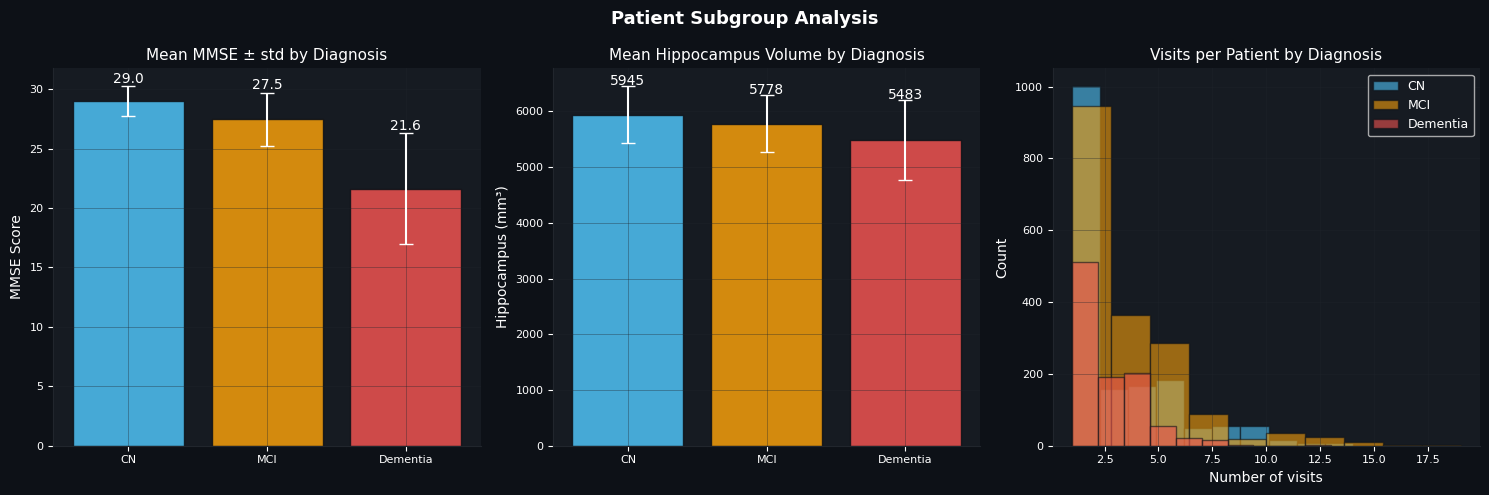

Saved → results/visualizations/subgroup_analysis.png


In [7]:
# ── Cell 7: Figure 5 — Error analysis by patient subgroup ─────────────
#
# Shows where the LSTM model makes larger vs smaller errors
# Uses residuals reconstructed from the metrics we already saved

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor(BG)

# Panel 1: Mean MMSE by DX (shows what the model is working with)
ax = axes[0]
style_ax(ax)
dx_mmse = df.groupby('DX')['MMSE'].agg(['mean','std']).loc[['CN','MCI','Dementia']]
ax.bar(dx_mmse.index, dx_mmse['mean'],
       yerr=dx_mmse['std'], color=[C_CN,C_MCI,C_DEM],
       alpha=0.85, edgecolor=BG, capsize=5, ecolor='white')
ax.set_title('Mean MMSE ± std by Diagnosis', color=FG, fontsize=11)
ax.set_ylabel('MMSE Score', color=FG)
for i, (dx, row) in enumerate(dx_mmse.iterrows()):
    ax.text(i, row['mean']+row['std']+0.3, f"{row['mean']:.1f}",
            ha='center', color=FG, fontsize=10)

# Panel 2: Hippocampus volume by DX
ax = axes[1]
style_ax(ax)
dx_h = df.groupby('DX')['Hippocampus'].agg(['mean','std']).loc[['CN','MCI','Dementia']]
ax.bar(dx_h.index, dx_h['mean'],
       yerr=dx_h['std'], color=[C_CN,C_MCI,C_DEM],
       alpha=0.85, edgecolor=BG, capsize=5, ecolor='white')
ax.set_title('Mean Hippocampus Volume by Diagnosis', color=FG, fontsize=11)
ax.set_ylabel('Hippocampus (mm³)', color=FG)
for i, (dx, row) in enumerate(dx_h.iterrows()):
    ax.text(i, row['mean']+row['std']+20, f"{row['mean']:.0f}",
            ha='center', color=FG, fontsize=10)

# Panel 3: N visits per DX (shows data richness)
ax = axes[2]
style_ax(ax)
visits_per_pat = (df.dropna(subset=['DX'])
                    .groupby(['RID','DX'])
                    .size()
                    .reset_index(name='n_visits'))
for dx, color in [('CN',C_CN),('MCI',C_MCI),('Dementia',C_DEM)]:
    vals = visits_per_pat[visits_per_pat['DX']==dx]['n_visits']
    ax.hist(vals, bins=10, color=color, alpha=0.6, label=dx, edgecolor=BG)
ax.set_title('Visits per Patient by Diagnosis', color=FG, fontsize=11)
ax.set_xlabel('Number of visits', color=FG)
ax.set_ylabel('Count', color=FG)
ax.legend(facecolor=PANEL, labelcolor=FG, fontsize=9)

plt.suptitle('Patient Subgroup Analysis', color=FG, fontsize=13, fontweight='bold')
plt.tight_layout()
path5 = 'results/visualizations/subgroup_analysis.png'
plt.savefig(path5, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'Saved → {path5}')

In [8]:
# ── Cell 8: Summary ───────────────────────────────────────────────────
print('='*55)
print('NOTEBOOK 04 COMPLETE — All visualizations saved')
print('='*55)
files = [
    'results/visualizations/demo_trajectories.png',
    'results/visualizations/hippocampus_atrophy.png',
    'results/visualizations/population_trajectories.png',
    'results/visualizations/results_dashboard.png',
    'results/visualizations/subgroup_analysis.png',
]
for f in files:
    status = '✓' if os.path.exists(f) else '✗'
    print(f'  {status}  {f}')

print()
print('Paste these directly into your presentation slides.')
print('Next: 05_simulation.ipynb  (Thursday)')

NOTEBOOK 04 COMPLETE — All visualizations saved
  ✓  results/visualizations/demo_trajectories.png
  ✓  results/visualizations/hippocampus_atrophy.png
  ✓  results/visualizations/population_trajectories.png
  ✓  results/visualizations/results_dashboard.png
  ✓  results/visualizations/subgroup_analysis.png

Paste these directly into your presentation slides.
Next: 05_simulation.ipynb  (Thursday)
